# Question 1 

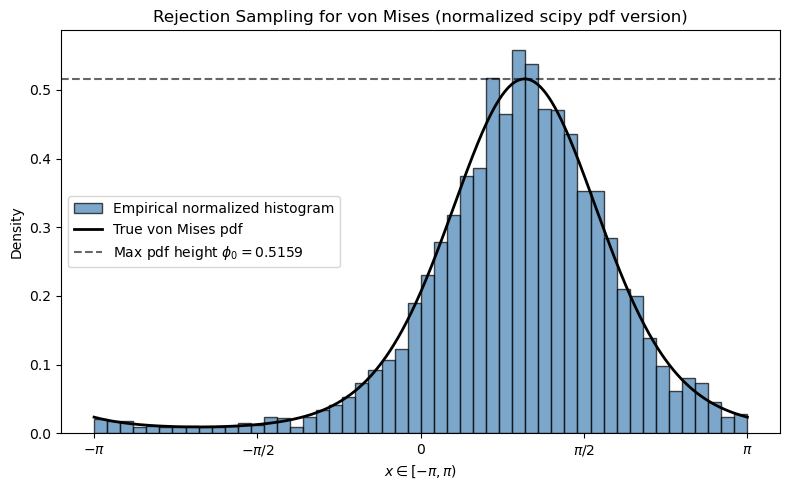

In [1]:
# normalized scale with proportinal constant 1/2piI0(kappa)
# with scipy function

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import vonmises

def rejection_sampling_vonMises_pdf(n_samples, kappa, mu):
    # max of the true normalized von Mises pdf
    phi_0 = vonmises.pdf(mu, kappa, loc=mu) # with scipy

    Z = []
    while len(Z) < n_samples:
        y = np.random.uniform(-np.pi, np.pi)
        u = np.random.uniform(0, 1)

        if u <= vonmises.pdf(y, kappa, loc=mu) / phi_0:
            Z.append(y)

    return np.array(Z), phi_0


# parameters
np.random.seed(42)
kappa = 2
mu = 1
n = 5000
bins = 50
x_split = 1000

Z, phi_0 = rejection_sampling_vonMises_pdf(n, kappa, mu)
x = np.linspace(-np.pi, np.pi, x_split)

plt.figure(figsize=(8, 5))

plt.hist( Z, bins=bins, density=True, range=(-np.pi, np.pi), color='steelblue', edgecolor='black', alpha=0.7, 
         label='Empirical normalized histogram'
)

plt.plot(
    x, vonmises.pdf(x, kappa, loc=mu),'k-', lw=2, label='True von Mises pdf'
)

plt.axhline( phi_0, color='black', linestyle='--', alpha=0.6, label=rf'Max pdf height $\phi_0 = {phi_0:.4f}$'
)

plt.title('Rejection Sampling for von Mises (normalized scipy pdf version)')
plt.xlabel(r'$x \in [-\pi, \pi)$')
plt.ylabel('Density')
plt.xticks( [-np.pi, -np.pi/2, 0, np.pi/2, np.pi], [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$']
)
plt.legend()
plt.tight_layout()
plt.show()

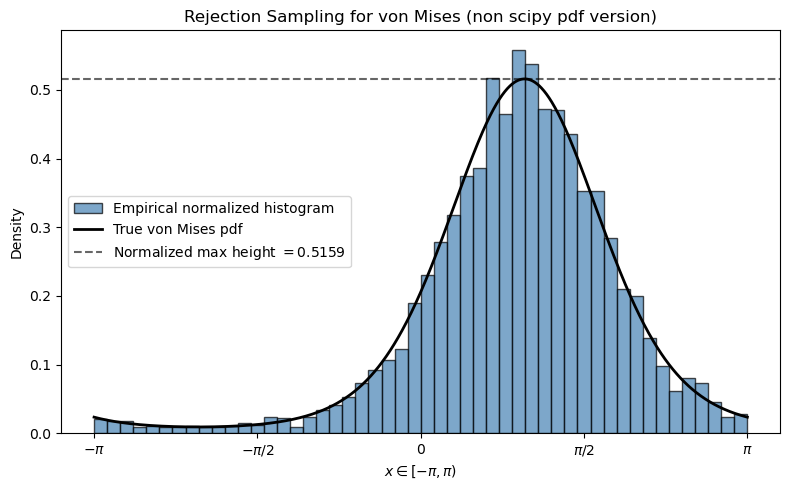

In [2]:
# NO scipy function with NO proportinal constant 1/2piI0(kappa)
# f(x) prop e^{\kappa \cos(x - \mu)}
# phi_0 = e^kappa

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import vonmises
from scipy.special import i0

def rejection_sampling_vonMises_kernel(n_samples, kappa, mu):
    # Calculate \phi_0 (Max value of von Mises PDF)
    phi_0 = np.exp(kappa) # un-normalized 

    Z = []
    while len(Z) < n_samples:
        y = np.random.uniform(-np.pi, np.pi)
        u = np.random.uniform(0, 1)

        if u <= np.exp(kappa * (np.cos(y - mu) - 1)):
            Z.append(y)

    return np.array(Z), phi_0


# parameters
np.random.seed(42)
kappa = 2
mu = 1
n = 5000
bins = 50
x_split = 1000

Z, phi_0 = rejection_sampling_vonMises_kernel(n, kappa, mu)
x = np.linspace(-np.pi, np.pi, x_split)

# convert phi_0 max to normalized pdf max for plotting on density scale
phi_0_density = phi_0 / (2 * np.pi * i0(kappa))

plt.figure(figsize=(8, 5))

plt.hist( Z, bins=bins, density=True, range=(-np.pi, np.pi), color='steelblue', edgecolor='black', alpha=0.7,
         label='Empirical normalized histogram'
)

pdf_true = vonmises.pdf(x, kappa, loc=mu)
plt.plot(x, pdf_true, 'k-', lw=2, label='True von Mises pdf'
)

plt.axhline( phi_0_density, color='black', linestyle='--', alpha=0.6, label=rf'Normalized max height $= {phi_0_density:.4f}$'
)

#plt.axhline( phi_0, color='blue', linestyle='--', alpha=0.6, label=rf'un-normalized max height $= {phi_0:.4f}$'
#) # phi_0 = e^kappa

plt.title('Rejection Sampling for von Mises (non scipy pdf version)')
plt.xlabel(r'$x \in [-\pi, \pi)$')
plt.ylabel('Density')
plt.xticks( [-np.pi, -np.pi/2, 0, np.pi/2, np.pi], [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$']
)
plt.legend()
plt.tight_layout()
plt.show()

# Question 2

Statistics for Z on [0, 4]
------------------------------
Mean     : 1.253280
Variance : 0.421801
Skewness : 0.614181
Kurtosis : 0.141288


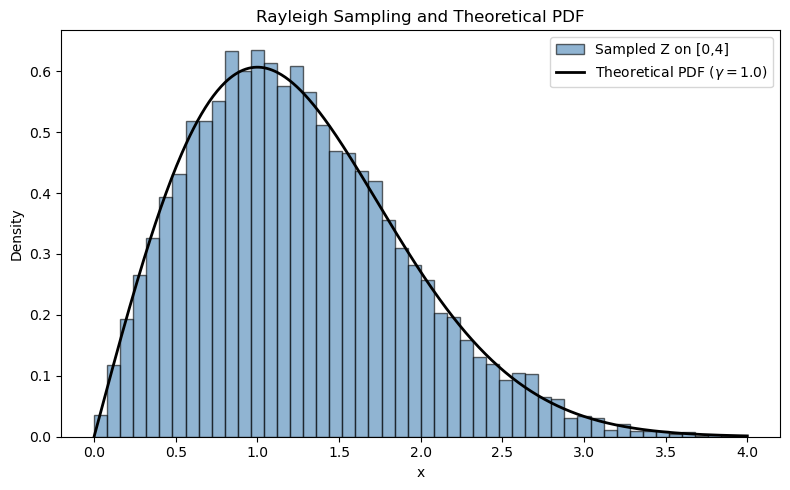

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rayleigh

# inverse transform
def generate_rayleigh(n, gamma):
    u = np.random.uniform(0, 1, size=n)
    return np.sqrt(-2 * gamma * np.log(1 - u))

# given pdfe
def rayleigh_pdf(x, gamma):
    return np.where(x >= 0, (x / gamma) * np.exp(-x**2 / (2 * gamma)), 0.0)

# scipy distribution
def generate_scipyrayleigh(n, gamma):
    return rayleigh.rvs(scale=np.sqrt(gamma), size=n)

# parameters
n = 10000
gamma = 1.0
k = 50
range_min, range_max = 0, 4 # partition [0,4]

Z = generate_rayleigh(n, gamma)
Z_interval = Z[(Z >= range_min) & (Z <= range_max)] # count phi for each interval

# statistics for Z on [0,4]
print("Statistics for Z on [0, 4]")
print("-" * 30)
print(f"Mean     : {np.mean(Z_interval):.6f}")
print(f"Variance : {np.var(Z_interval, ddof=1):.6f}")
print(f"Skewness : {skew(Z_interval):.6f}")
print(f"Kurtosis : {kurtosis(Z_interval):.6f}")


# plot
plt.figure(figsize=(8, 5))

plt.hist(
    Z_interval,
    bins=k, # k = 50 intervals 
    range=(range_min, range_max), # partition [0,4]
    density=True, # normalize by n
    alpha=0.6,
    color='steelblue',
    edgecolor='black',
    label='Sampled Z on [0,4]'
)

x = np.linspace(range_min, range_max, 500)
f_x = rayleigh_pdf(x, gamma) # true pdf

plt.plot(x, f_x, '-', c='black', lw=2,
         label=rf'Theoretical PDF ($\gamma={gamma}$)')

plt.title("Rayleigh Sampling and Theoretical PDF")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


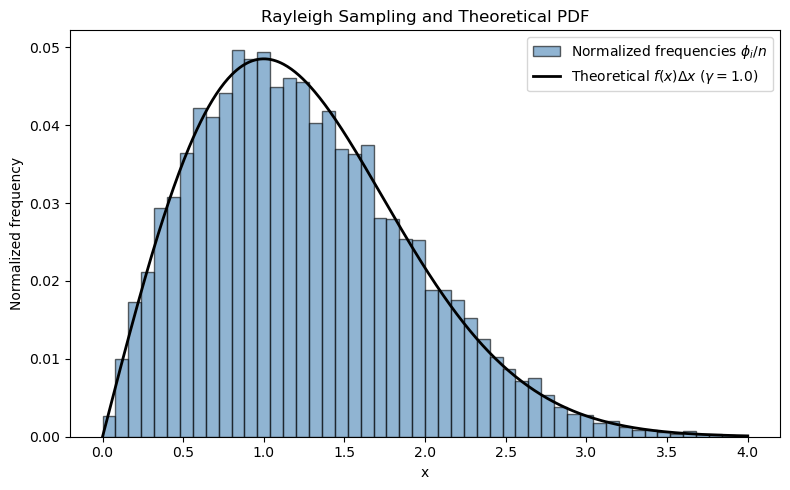

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rayleigh

# inverse transform
def generate_rayleigh(n, gamma):
    u = np.random.uniform(0, 1, size=n)
    return np.sqrt(-2 * gamma * np.log(1 - u))

def rayleigh_pdf(x, gamma):
    return np.where(x >= 0, (x / gamma) * np.exp(-x**2 / (2 * gamma)), 0.0)

# scipy distribution
def generate_scipyrayleigh(n, gamma):
    return rayleigh.rvs(scale=np.sqrt(gamma), size=n)

# parameters
n = 10000
gamma = 1.0
k = 50
range_min, range_max = 0, 4

Z = generate_rayleigh(n, gamma)
Z_interval = Z[(Z >= range_min) & (Z <= range_max)]

# bin width
bin_width = (range_max - range_min) / k

# plot
plt.figure(figsize=(8, 5))

plt.hist(
    Z_interval,
    bins=k,
    range=(range_min, range_max),
    weights=np.ones_like(Z_interval) / n,   # normalize by n
    alpha=0.6,
    color='steelblue',
    edgecolor='black',
    label=r'Normalized frequencies $\phi_i/n$'
)

x = np.linspace(range_min, range_max, 500)
f_x = rayleigh_pdf(x, gamma)

# scale pdf by bin width so it matches probability-per-bin bars
plt.plot(
    x, f_x * bin_width,
    '-', c='black', lw=2,
    label=rf'Theoretical $f(x)\Delta x$ ($\gamma={gamma}$)'
)

plt.title("Rayleigh Sampling and Theoretical PDF")
plt.xlabel("x")
plt.ylabel("Normalized frequency")
plt.legend()
plt.tight_layout()
plt.show()

## Question 3

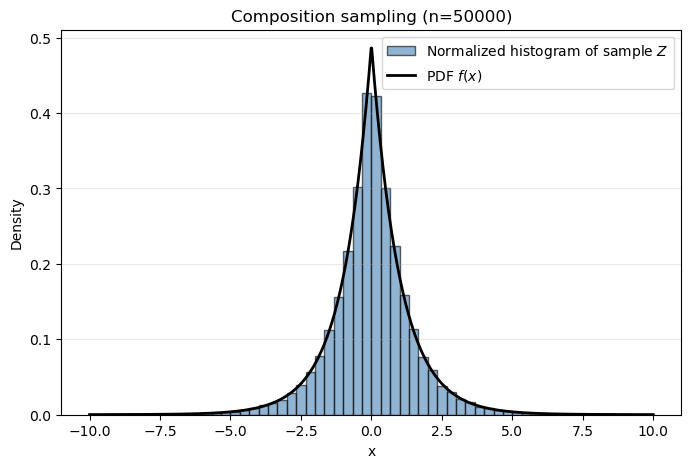

Mean estimate     = -0.07482033718236492
Variance estimate = 202.54557446442394
Skew estimate     = -97.40510348006077
Kurtosis estimate = 12690.553333263431


In [4]:
# 3b

import numpy as np
import matplotlib.pyplot as plt

def generate_composition(n):
    u_1 = np.random.uniform(0, 1, n) # choose distribution
    u_2 = np.random.uniform(0, 1, n) # generate samples
    z = np.empty(n)

    z_laplace = np.where(u_2 < 0.5, np.log(2 * u_2), -np.log(2 * (1 - u_2)))
    z_cauchy = np.tan(np.pi * (u_2 - 0.5))

    z = np.where(u_1 < 0.95, z_laplace, z_cauchy)
    return z

# parameters
n = 50000
Z = generate_composition(n)

x = np.linspace(-10, 10, 1000)

# plot
plt.figure(figsize=(8, 5))
plt.hist(Z, bins=60, range=(-10, 10), density=True, alpha=0.6,
         edgecolor='black', color='steelblue', label='Normalized histogram of sample $Z$') # normalized histogram

# superimpose f(x)
f_x = 0.475 * np.exp(-np.abs(x)) + (0.05 / np.pi) * (1 / (1 + x**2)) # given f(x) 
plt.plot(x, f_x, '-', color = 'black', lw=2, label='PDF $f(x)$')

plt.title(f"Composition sampling (n={n})")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3c

from scipy import stats

mean = np.mean(Z) # sample mean
var = np.var(Z, ddof=1) # sample var

skew = stats.skew(Z)
kurtosis = stats.kurtosis(Z)

print("Mean estimate     =", mean)
print("Variance estimate =", var)
print("Skew estimate     =", skew)
print("Kurtosis estimate =", kurtosis)